## Problem Statement

E-commerce platforms generate large amounts of customer behavioral and
transaction-related data. Identifying customers who are likely to churn can
help businesses understand customer behavior and support data-driven
customer retention strategies.

The objective of this project is to analyze customer data and develop a
machine learning classification model that predicts whether a customer is
likely to churn based on their available behavioral and demographic
characteristics.


## Project Objectives

1. Analyze e-commerce customer behavior using data analytics techniques.
2. Understand the factors associated with customer churn.
3. Clean and preprocess the dataset.
4. Perform exploratory data analysis.
5. Engineer meaningful features for machine learning.
6. Develop classification models for churn prediction.
7. Evaluate the models using appropriate classification metrics.
8. Save the trained machine learning pipeline.
9. Deploy the model using Flask.
10. Provide individual and batch customer churn prediction.

# E-Commerce Customer Churn Prediction Using Machine Learning

### IBM SkillsBuild Data Analytics with AI Internship 2026

**Author:** Deepak Kumar Rajak

---

## Project Overview

Customer churn is an important business problem in the e-commerce industry.
Customers who stop purchasing from an e-commerce platform can negatively
affect revenue and long-term customer relationships.

This project aims to analyze e-commerce customer behavior and develop a
machine learning classification system to predict whether a customer is
likely to churn.

The project follows an end-to-end machine learning workflow including:

- Data understanding
- Data cleaning and preprocessing
- Exploratory data analysis
- Feature engineering
- Machine learning model development
- Model evaluation
- Model persistence
- Flask-based deployment
- Individual customer prediction
- Batch prediction
- Analytics dashboard

In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


In [5]:
# Display only columns containing missing values
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
print(missing_summary)

Columns with missing values:
Tenure               194
WarehouseToHome      169
DaySinceLastOrder    213
dtype: int64


In [6]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 671


In [7]:
# Check target distribution
churn_counts = df["Churn"].value_counts()

print("Churn Distribution:")
print(churn_counts)

Churn Distribution:
Churn
0    3267
1     674
Name: count, dtype: int64


In [8]:
# Check target percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn Percentage:")
print(churn_percentage.round(2))

Churn Percentage:
Churn
0    82.9
1    17.1
Name: proportion, dtype: float64


In [9]:
# Check number of unique values in each column
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
Tenure                        36
WarehouseToHome               33
NumberOfDeviceRegistered       6
PreferedOrderCat               6
SatisfactionScore              5
MaritalStatus                  3
NumberOfAddress               14
Complain                       2
DaySinceLastOrder             22
CashbackAmount              2335
Churn                          2
dtype: int64


In [11]:
for column in df.columns:
    print(repr(column))

'Tenure'
'WarehouseToHome'
'NumberOfDeviceRegistered'
'PreferedOrderCat'
'SatisfactionScore'
'MaritalStatus'
'NumberOfAddress'
'Complain'
'DaySinceLastOrder'
'CashbackAmount'
'Churn'


In [2]:
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())
print("DataFrame type:", type(df))

DataFrame shape: (3941, 11)
Columns: ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']
DataFrame type: <class 'pandas.core.frame.DataFrame'>


In [5]:
# Clean column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


In [7]:
import pandas as pd

# Reload the dataset from scratch
df = pd.read_csv("../data/raw/data_ecommerce_customer_churn.csv")

print("Shape:", df.shape)

print("\nExact columns:")
for col in df.columns:
    print(repr(col))

print("\nFourth column values:")
print(df.iloc[:, 3].value_counts())

Shape: (3941, 11)

Exact columns:
'Tenure'
'WarehouseToHome'
'NumberOfDeviceRegistered'
'PreferedOrderCat'
'SatisfactionScore'
'MaritalStatus'
'NumberOfAddress'
'Complain'
'DaySinceLastOrder'
'CashbackAmount'
'Churn'

Fourth column values:
PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone           887
Fashion                585
Mobile                 559
Grocery                273
Others                 179
Name: count, dtype: int64


In [8]:
# Standardize column names
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


In [9]:
# Get categorical column names directly from the dataframe
preferred_order_col = df.columns[3]
marital_status_col = df.columns[5]

print("Preferred Order Categories:")
print(df[preferred_order_col].value_counts())

print("\nMarital Status:")
print(df[marital_status_col].value_counts())

Preferred Order Categories:
PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone           887
Fashion                585
Mobile                 559
Grocery                273
Others                 179
Name: count, dtype: int64

Marital Status:
MaritalStatus
Married     2055
Single      1310
Divorced     576
Name: count, dtype: int64


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 671


In [12]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn Distribution:
Churn
0    3267
1     674
Name: count, dtype: int64

Churn Percentage:
Churn
0    82.9
1    17.1
Name: proportion, dtype: float64


In [13]:
print("Unique values in each column:")
print(df.nunique())

Unique values in each column:
Tenure                        36
WarehouseToHome               33
NumberOfDeviceRegistered       6
PreferedOrderCat               6
SatisfactionScore              5
MaritalStatus                  3
NumberOfAddress               14
Complain                       2
DaySinceLastOrder             22
CashbackAmount              2335
Churn                          2
dtype: int64


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure,3747.0,10.081398,8.498864,0.0,2.0,9.00,16.00,61.00
WarehouseToHome,3772.0,15.650583,8.452301,5.0,9.0,14.00,21.00,127.00
NumberOfDeviceRegistered,3941.0,3.679269,1.013938,1.0,3.0,4.00,4.00,6.00
SatisfactionScore,3941.0,3.088302,1.381832,1.0,2.0,3.00,4.00,5.00
NumberOfAddress,3941.0,4.237757,2.626699,1.0,2.0,3.00,6.00,22.00
Complain,3941.0,0.282416,0.450232,0.0,0.0,0.00,1.00,1.00
DaySinceLastOrder,3728.0,4.531652,3.667648,0.0,2.0,3.00,7.00,46.00
CashbackAmount,3941.0,176.707419,48.791784,0.0,145.7,163.34,195.25,324.99
Churn,3941.0,0.171023,0.376576,0.0,0.0,0.00,0.00,1.00


In [15]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows before cleaning: {duplicate_count}")

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset shape after removing duplicates: {df.shape}")
print(f"Duplicate rows after cleaning: {df.duplicated().sum()}")

Duplicate rows before cleaning: 671
Dataset shape after removing duplicates: (3270, 11)
Duplicate rows after cleaning: 0


## 2.2 Handling Missing Values

After removing duplicate records, missing values are checked again. The dataset contains missing values in three numerical features: `Tenure`, `WarehouseToHome`, and `DaySinceLastOrder`.

Since these are numerical variables, median imputation will be used. Median imputation is less sensitive to extreme values than mean imputation.

In [16]:
# Check missing values after duplicate removal
print("Missing values before imputation:")
print(df.isnull().sum())

# Fill numerical missing values using the median
missing_columns = ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]

for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after imputation:")
print(df.isnull().sum())

Missing values before imputation:
Tenure                      160
WarehouseToHome             135
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64

Missing values after imputation:
Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


## 2.3 Data Type and Feature Analysis

The cleaned dataset is inspected to identify numerical and categorical features. This is important because numerical and categorical variables require different preprocessing techniques before machine learning.

In [17]:
# Check data types
print("Data Types:")
print(df.dtypes)

Data Types:
Tenure                      float64
WarehouseToHome             float64
NumberOfDeviceRegistered      int64
PreferedOrderCat             object
SatisfactionScore             int64
MaritalStatus                object
NumberOfAddress               int64
Complain                      int64
DaySinceLastOrder           float64
CashbackAmount              float64
Churn                         int64
dtype: object


In [18]:
# Identify numerical and categorical features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from feature lists
numerical_features.remove("Churn")

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

Categorical Features:
['PreferedOrderCat', 'MaritalStatus']


## 2.4 Separating Features and Target

The target variable `Churn` is separated from the input features. The input features will be used to train the classification models, while `Churn` will be the prediction target.

In [19]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (3270, 10)
Target shape: (3270,)

Target distribution:
Churn
0    2736
1     534
Name: count, dtype: int64


In [20]:
print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

Feature columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

Target column:
Churn


## 2.5 Train-Test Split

The cleaned dataset is divided into training and testing subsets. A stratified split is used so that the proportion of churn and non-churn customers remains approximately consistent in both subsets.

The test set contains 20% of the data, while 80% is used for training.

In [21]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training feature shape: (2616, 10)
Testing feature shape: (654, 10)

Training target distribution:
Churn
0    0.837
1    0.163
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


## 2.6 Feature Preprocessing

Numerical and categorical features require different preprocessing techniques.

For numerical features, missing values are handled using median imputation and features are standardized using `StandardScaler`.

For categorical features, missing values are handled using the most frequent category and categorical variables are converted into numerical form using `OneHotEncoder`.

A `ColumnTransformer` is used to combine both preprocessing strategies into a single pipeline.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")
print(preprocessor)

Preprocessing pipeline created successfully!
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tenure', 'WarehouseToHome',
                                  'NumberOfDeviceRegistered',
                                  'SatisfactionScore', 'NumberOfAddress',
                                  'Complain', 'DaySinceLastOrder',
                                  'CashbackAmount']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                     

In [23]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (2616, 17)
Testing processed shape: (654, 17)


In [24]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed feature names:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of processed features: 17

Processed feature names:
1. num__Tenure
2. num__WarehouseToHome
3. num__NumberOfDeviceRegistered
4. num__SatisfactionScore
5. num__NumberOfAddress
6. num__Complain
7. num__DaySinceLastOrder
8. num__CashbackAmount
9. cat__PreferedOrderCat_Fashion
10. cat__PreferedOrderCat_Grocery
11. cat__PreferedOrderCat_Laptop & Accessory
12. cat__PreferedOrderCat_Mobile
13. cat__PreferedOrderCat_Mobile Phone
14. cat__PreferedOrderCat_Others
15. cat__MaritalStatus_Divorced
16. cat__MaritalStatus_Married
17. cat__MaritalStatus_Single


In [25]:
# Save cleaned dataset
processed_path = "../data/processed/cleaned_ecommerce_customer_churn.csv"

df.to_csv(processed_path, index=False)

print(f"Cleaned dataset saved successfully!")
print(f"Location: {processed_path}")
print(f"Shape: {df.shape}")

Cleaned dataset saved successfully!
Location: ../data/processed/cleaned_ecommerce_customer_churn.csv
Shape: (3270, 11)


In [26]:
# Verify saved dataset
cleaned_df = pd.read_csv(processed_path)

print("Saved dataset shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

Saved dataset shape: (3270, 11)
Missing values: 0
Duplicate rows: 1


In [27]:
# Final duplicate check after imputation

duplicates_after_imputation = df.duplicated().sum()

print("Duplicates after imputation:", duplicates_after_imputation)

if duplicates_after_imputation > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Final dataset shape:", df.shape)
print("Final duplicate count:", df.duplicated().sum())
print("Final missing value count:", df.isnull().sum().sum())

Duplicates after imputation: 1
Final dataset shape: (3269, 11)
Final duplicate count: 0
Final missing value count: 0


In [28]:
# Save final cleaned dataset

processed_path = "../data/processed/cleaned_ecommerce_customer_churn.csv"

df.to_csv(processed_path, index=False)

print("Final cleaned dataset saved successfully!")
print("Shape:", df.shape)

Final cleaned dataset saved successfully!
Shape: (3269, 11)


In [29]:
# Final verification

cleaned_df = pd.read_csv(processed_path)

print("Saved dataset shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

Saved dataset shape: (3269, 11)
Missing values: 0
Duplicate rows: 0


In [30]:
# Recreate features and target after final cleaning

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3269, 10)
Target shape: (3269,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training feature shape: (2615, 10)
Testing feature shape: (654, 10)

Training target distribution:
Churn
0    0.837
1    0.163
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


In [32]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (2615, 17)
Testing processed shape: (654, 17)


In [34]:
import sys
import os

sys.path.append(os.path.abspath(".."))

print(os.getcwd())
print("src path added successfully")

c:\Users\LENOVO\ecommerce-customer-churn\notebooks
src path added successfully


In [35]:
from src.preprocessing import (
    load_data,
    clean_data,
    create_preprocessor,
    prepare_features
)

print("Preprocessing module imported successfully!")

Preprocessing module imported successfully!


In [36]:
# Load dataset
df = load_data("../data/raw/data_ecommerce_customer_churn.csv")

print("Dataset loaded successfully!")
print("Original shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Original shape: (3941, 11)
   Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0    15.0             29.0                         4  Laptop & Accessory   
1     7.0             25.0                         4              Mobile   
2    27.0             13.0                         3  Laptop & Accessory   
3    20.0             25.0                         4             Fashion   
4    30.0             15.0                         4              Others   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  3        Single                2         0   
1                  1       Married                2         0   
2                  1       Married                5         0   
3                  3      Divorced                7         0   
4                  4        Single                8         0   

   DaySinceLastOrder  CashbackAmount  Churn  
0                7.0          143.32      0  
1   

In [37]:
# Clean dataset
df_clean = clean_data(df)

print("Dataset cleaned successfully!")
print("Cleaned shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Dataset cleaned successfully!
Cleaned shape: (3269, 11)
Missing values: 0
Duplicate rows: 0


In [38]:
# Prepare features and target
X, y = prepare_features(df_clean)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (3269, 10)
Target shape: (3269,)

Target distribution:
Churn
0    2735
1     534
Name: count, dtype: int64


In [39]:
# Create preprocessing pipeline
preprocessor = create_preprocessor(df_clean)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [40]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training shape: (2615, 10)
Testing shape: (654, 10)

Training target distribution:
Churn
0    0.837
1    0.163
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


In [41]:
# Fit preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (2615, 17)
Processed testing shape: (654, 17)


In [6]:
print("X columns:")
print(X.columns.tolist())

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nExpected categorical columns:")
print(["PreferredOrderCat", "MaritalStatus"])

X columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

X_train columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

Expected categorical columns:
['PreferredOrderCat', 'MaritalStatus']


In [8]:
import sys
import os
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.preprocessing as preprocessing

# Reload the updated Python file
importlib.reload(preprocessing)

print("preprocessing.py reloaded successfully!")

preprocessing.py reloaded successfully!


In [10]:
print("X_train type:", type(X_train))

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nMissing expected categorical columns:")

for col in ["PreferredOrderCat", "MaritalStatus"]:
    print(col, "->", col not in X_train.columns)

X_train type: <class 'pandas.core.frame.DataFrame'>

X_train columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

Missing expected categorical columns:
PreferredOrderCat -> True
MaritalStatus -> False


In [2]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

import src.preprocessing as preprocessing

print("Preprocessing module imported successfully!")

Preprocessing module imported successfully!


In [4]:
file_path = "../data/raw/data_ecommerce_customer_churn.csv"

df = preprocessing.load_data(file_path)

print("Original dataset shape:", df.shape)

Original dataset shape: (3941, 11)


In [5]:
df_clean = preprocessing.clean_data(df)

print("Cleaned dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows before cleaning: 671
Shape after removing duplicates: (3270, 11)

Missing values before imputation:
Tenure               160
WarehouseToHome      135
DaySinceLastOrder    181
dtype: int64

Missing values after imputation:
Tenure               0
WarehouseToHome      0
DaySinceLastOrder    0
dtype: int64

Final duplicate rows: 0
Cleaned dataset shape: (3269, 11)
Missing values: 0
Duplicate rows: 0


In [6]:
# Prepare features and target

X, y = preprocessing.prepare_features(df_clean)

print("Features:", X.shape)
print("Target:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features: (3269, 10)
Target: (3269,)

Feature columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']


In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training feature shape: (2615, 10)
Testing feature shape: (654, 10)

Training target distribution:
Churn
0    0.837
1    0.163
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.836
1    0.164
Name: proportion, dtype: float64


In [9]:
import importlib
import src.preprocessing as preprocessing

preprocessing = importlib.reload(preprocessing)

print("Preprocessing module reloaded successfully!")

Preprocessing module reloaded successfully!


In [10]:
print(df_clean.columns.tolist())

['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']


In [12]:
import importlib
import src.preprocessing as preprocessing

preprocessing = importlib.reload(preprocessing)

print("Updated preprocessing module loaded!")

Updated preprocessing module loaded!


In [14]:
print("df_clean columns:")
for i, col in enumerate(df_clean.columns):
    print(i, repr(col))

print("\nChecking PreferredOrderCat:")
print("Exists:", "PreferredOrderCat" in df_clean.columns)

print("\nDataFrame shape:")
print(df_clean.shape)

df_clean columns:
0 'Tenure'
1 'WarehouseToHome'
2 'NumberOfDeviceRegistered'
3 'PreferedOrderCat'
4 'SatisfactionScore'
5 'MaritalStatus'
6 'NumberOfAddress'
7 'Complain'
8 'DaySinceLastOrder'
9 'CashbackAmount'
10 'Churn'

Checking PreferredOrderCat:
Exists: False

DataFrame shape:
(3269, 11)


In [15]:
print("Original df columns:")
for i, col in enumerate(df.columns):
    print(i, repr(col))

Original df columns:
0 'Tenure'
1 'WarehouseToHome'
2 'NumberOfDeviceRegistered'
3 'PreferedOrderCat'
4 'SatisfactionScore'
5 'MaritalStatus'
6 'NumberOfAddress'
7 'Complain'
8 'DaySinceLastOrder'
9 'CashbackAmount'
10 'Churn'


In [16]:
actual_column = df_clean.columns[3]
expected_column = "PreferredOrderCat"

print("Actual :", repr(actual_column))
print("Expected:", repr(expected_column))

print("\nAre they equal?")
print(actual_column == expected_column)

print("\nLengths:")
print("Actual length  :", len(actual_column))
print("Expected length:", len(expected_column))

print("\nCharacter codes:")
print("Actual  :", [ord(c) for c in actual_column])
print("Expected:", [ord(c) for c in expected_column])

Actual : 'PreferedOrderCat'
Expected: 'PreferredOrderCat'

Are they equal?
False

Lengths:
Actual length  : 16
Expected length: 17

Character codes:
Actual  : [80, 114, 101, 102, 101, 114, 101, 100, 79, 114, 100, 101, 114, 67, 97, 116]
Expected: [80, 114, 101, 102, 101, 114, 114, 101, 100, 79, 114, 100, 101, 114, 67, 97, 116]


In [17]:
print("\nAll columns with length:")
for col in df_clean.columns:
    print(repr(col), "-> length:", len(col))


All columns with length:
'Tenure' -> length: 6
'WarehouseToHome' -> length: 15
'NumberOfDeviceRegistered' -> length: 24
'PreferedOrderCat' -> length: 16
'SatisfactionScore' -> length: 17
'MaritalStatus' -> length: 13
'NumberOfAddress' -> length: 15
'Complain' -> length: 8
'DaySinceLastOrder' -> length: 17
'CashbackAmount' -> length: 14
'Churn' -> length: 5


In [18]:
import importlib
import src.preprocessing as preprocessing

preprocessing = importlib.reload(preprocessing)

print("Preprocessing module reloaded successfully!")

Preprocessing module reloaded successfully!


In [19]:
df_clean = preprocessing.clean_data(df)

print("Cleaned dataset shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nPreferredOrderCat exists:",
      "PreferredOrderCat" in df_clean.columns)

Cleaned dataset shape: (3269, 11)

Columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferredOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn']

PreferredOrderCat exists: True


In [20]:
X, y = preprocessing.prepare_features(df_clean)

print("Features:", X.shape)
print("Target:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features: (3269, 10)
Target: (3269,)

Feature columns:
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferredOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (2615, 10)
Testing feature shape: (654, 10)

Training target distribution:
Churn
0    2188
1     427
Name: count, dtype: int64

Testing target distribution:
Churn
0    547
1    107
Name: count, dtype: int64


In [22]:
preprocessor = preprocessing.create_preprocessor(X_train)

print("Preprocessing pipeline created successfully!")
print(preprocessor)

Preprocessing pipeline created successfully!
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tenure', 'WarehouseToHome',
                                  'NumberOfDeviceRegistered',
                                  'SatisfactionScore', 'NumberOfAddress',
                                  'Complain', 'DaySinceLastOrder',
                                  'CashbackAmount']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                     

In [23]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (2615, 17)
Testing processed shape: (654, 17)


In [24]:
feature_names = preprocessing.get_feature_names(preprocessor)

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
for feature in feature_names:
    print(feature)

Number of processed features: 17

Processed feature names:
num__Tenure
num__WarehouseToHome
num__NumberOfDeviceRegistered
num__SatisfactionScore
num__NumberOfAddress
num__Complain
num__DaySinceLastOrder
num__CashbackAmount
cat__PreferredOrderCat_Fashion
cat__PreferredOrderCat_Grocery
cat__PreferredOrderCat_Laptop & Accessory
cat__PreferredOrderCat_Mobile
cat__PreferredOrderCat_Mobile Phone
cat__PreferredOrderCat_Others
cat__MaritalStatus_Divorced
cat__MaritalStatus_Married
cat__MaritalStatus_Single


In [25]:
df_clean.to_csv(
    "../data/processed/cleaned_ecommerce_customer_churn.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Shape:", df_clean.shape)

Cleaned dataset saved successfully!
Shape: (3269, 11)


In [26]:
print("Dataset Shape:", df_clean.shape)

print("\nBasic Statistics:")
display(df_clean.describe())

Dataset Shape: (3269, 11)

Basic Statistics:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3269.000000,3269.000000,3269.000000,3269.000000,3269.000000,3269.000000,3269.000000,3269.00000,3269.000000
mean,10.127868,15.406240,3.676354,3.020496,4.223004,0.281738,4.460385,177.40115,0.163353
std,8.438172,8.405689,1.017530,1.395221,2.623593,0.449915,3.610052,49.30914,0.369744
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.89000,0.000000
50%,9.000000,13.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.88000,0.000000
75%,15.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,197.13000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.99000,1.000000


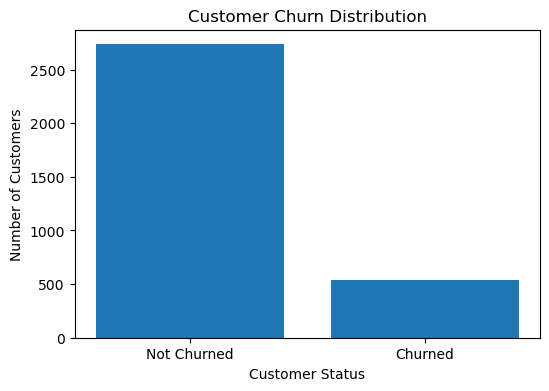

Churn distribution:
Churn
0    2735
1     534
Name: count, dtype: int64


In [27]:
import matplotlib.pyplot as plt

churn_counts = df_clean["Churn"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Churned", "Churned"], churn_counts.values)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

print("Churn distribution:")
print(churn_counts)

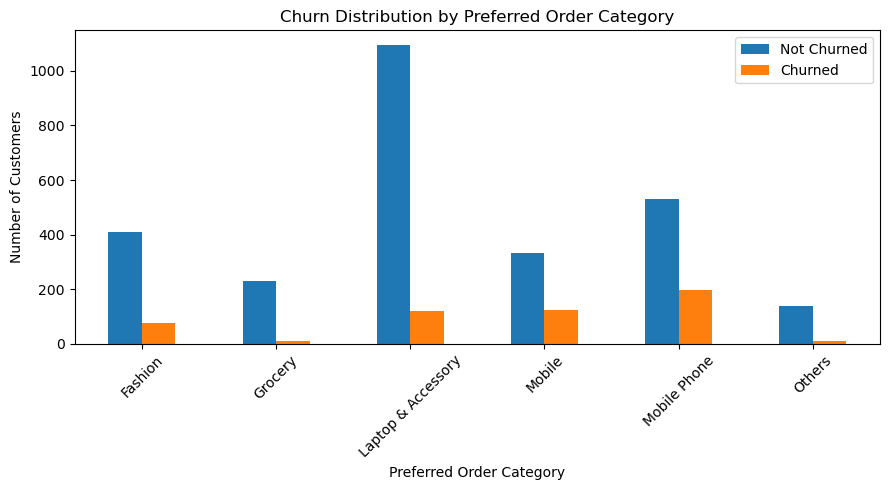

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

category_churn = pd.crosstab(
    df_clean["PreferredOrderCat"],
    df_clean["Churn"]
)

category_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Preferred Order Category")
plt.ylabel("Number of Customers")
plt.title("Churn Distribution by Preferred Order Category")
plt.xticks(rotation=45)
plt.legend(["Not Churned", "Churned"])
plt.tight_layout()
plt.show()

In [29]:
category_churn_rate = (
    df_clean.groupby("PreferredOrderCat")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

print("Churn Rate by Preferred Order Category:")
print((category_churn_rate * 100).round(2))

Churn Rate by Preferred Order Category:
PreferredOrderCat
Mobile                27.07
Mobile Phone          26.90
Fashion               15.50
Laptop & Accessory     9.81
Others                 7.38
Grocery                4.17
Name: Churn, dtype: float64


In [30]:
satisfaction_churn = (
    df_clean.groupby("SatisfactionScore")["Churn"]
    .mean() * 100
)

print("Churn Rate by Satisfaction Score:")
print(satisfaction_churn.round(2))

Churn Rate by Satisfaction Score:
SatisfactionScore
1    11.17
2    13.01
3    17.49
4    15.92
5    22.83
Name: Churn, dtype: float64


In [31]:
complaint_churn = (
    df_clean.groupby("Complain")["Churn"]
    .mean() * 100
)

print("Churn Rate by Complaint Status:")
print(complaint_churn.round(2))

Churn Rate by Complaint Status:
Complain
0    10.26
1    31.81
Name: Churn, dtype: float64


In [32]:
tenure_churn = (
    df_clean.groupby("Tenure")["Churn"]
    .mean() * 100
)

print("Churn Rate by Tenure:")
print(tenure_churn.round(2))

Churn Rate by Tenure:
Tenure
0.0     54.26
1.0     49.25
2.0      8.74
3.0     10.17
4.0      9.23
5.0      8.94
6.0      2.59
7.0      8.13
8.0      6.62
9.0     17.73
10.0     4.69
11.0     5.31
12.0     4.12
13.0     8.16
14.0     8.08
15.0     4.82
16.0     4.71
17.0     3.08
18.0     3.08
19.0     8.89
20.0    12.50
21.0     9.52
22.0     0.00
23.0     0.00
24.0     0.00
25.0     0.00
26.0     0.00
27.0     0.00
28.0     0.00
29.0     0.00
30.0     0.00
31.0     0.00
50.0     0.00
51.0     0.00
60.0     0.00
61.0     0.00
Name: Churn, dtype: float64


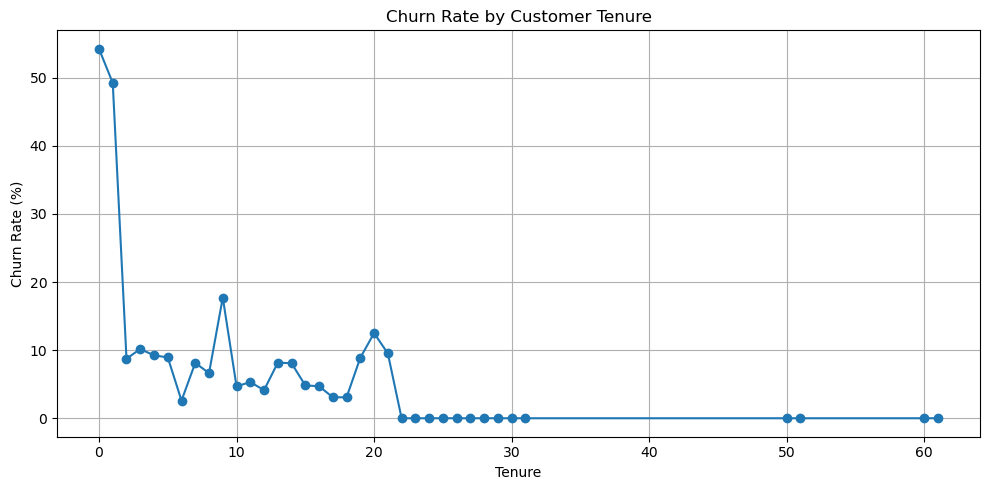

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o"
)

plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Customer Tenure")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
correlation = df_clean.corr(numeric_only=True)

print("Correlation with Churn:")
print(
    correlation["Churn"]
    .sort_values(ascending=False)
)

Correlation with Churn:
Churn                       1.000000
Complain                    0.262217
NumberOfDeviceRegistered    0.109660
SatisfactionScore           0.098498
WarehouseToHome             0.065579
NumberOfAddress             0.046344
DaySinceLastOrder          -0.143244
CashbackAmount             -0.151359
Tenure                     -0.336335
Name: Churn, dtype: float64


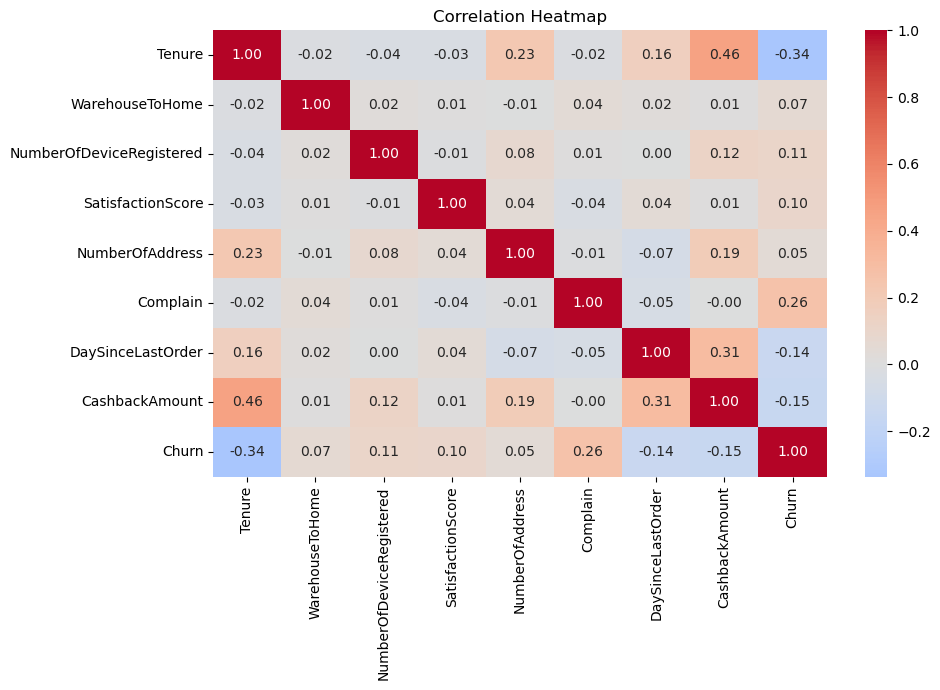

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## EDA Summary

The exploratory data analysis produced the following observations:

- The cleaned dataset contains 3,269 customer records.
- 2,735 customers did not churn, while 534 customers churned, resulting in an overall churn rate of approximately 16.3%.
- Churn rates vary across preferred order categories.
- Churn rates also vary across satisfaction scores.
- Customers with a recorded complaint have a higher observed churn rate than customers without a complaint.
- Customer tenure shows a negative correlation with churn (approximately -0.34).
- Complaint has the strongest positive numerical correlation with churn (approximately 0.26).
- The target variable is imbalanced, so multiple evaluation metrics should be considered during model evaluation rather than relying only on accuracy.
- These observations describe relationships present in the dataset and do not establish causation.

In [36]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

print("Baseline Logistic Regression trained successfully!")

Baseline Logistic Regression trained successfully!


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred = baseline_model.predict(X_test_processed)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-Score :", round(f1_score(y_test, y_pred), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Logistic Regression Results
------------------------------------
Accuracy : 0.8945
Precision: 0.75
Recall   : 0.5327
F1-Score : 0.623

Confusion Matrix:
[[528  19]
 [ 50  57]]


In [38]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print(baseline_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8944954128440367, 'Precision': 0.75, 'Recall': 0.5327102803738317, 'F1-Score': 0.6229508196721312}


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [40]:
rf_pred = rf_model.predict(X_test_processed)

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1-Score": f1_score(y_test, rf_pred)
}

print("Random Forest Results")
print("---------------------")
for metric, value in rf_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy: 0.9083
Precision: 0.7701
Recall: 0.6262
F1-Score: 0.6907

Confusion Matrix:
[[527  20]
 [ 40  67]]


In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [42]:
xgb_pred = xgb_model.predict(X_test_processed)

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1-Score": f1_score(y_test, xgb_pred)
}

print("XGBoost Results")
print("----------------")
for metric, value in xgb_results.items():
    if metric != "Model":
        print(f"{metric}: {value:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Results
----------------
Accuracy: 0.9113
Precision: 0.7526
Recall: 0.6822
F1-Score: 0.7157

Confusion Matrix:
[[523  24]
 [ 34  73]]


In [43]:
model_comparison = pd.DataFrame([
    baseline_results,
    rf_results,
    xgb_results
])

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.894495,0.750000,0.532710,0.622951
1,Random Forest,0.908257,0.770115,0.626168,0.690722
2,XGBoost,0.911315,0.752577,0.682243,0.715686


In [44]:
from sklearn.metrics import roc_auc_score

lr_prob = baseline_model.predict_proba(X_test_processed)[:, 1]
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

roc_results = {
    "Logistic Regression": roc_auc_score(y_test, lr_prob),
    "Random Forest": roc_auc_score(y_test, rf_prob),
    "XGBoost": roc_auc_score(y_test, xgb_prob)
}

print("ROC-AUC Scores")
print("--------------")

for model, score in roc_results.items():
    print(f"{model}: {score:.4f}")

ROC-AUC Scores
--------------
Logistic Regression: 0.9239
Random Forest: 0.9514
XGBoost: 0.9576


## Model Evaluation Summary

Three classification models were evaluated using the same test set:

- Logistic Regression was used as the baseline model.
- Random Forest was evaluated with balanced class weights.
- XGBoost was evaluated as a gradient boosting classifier.

The models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 89.45% | 75.00% | 53.27% | 62.30% | 92.39% |
| Random Forest | 90.83% | 77.01% | 62.62% | 69.07% | 95.14% |
| XGBoost | 91.13% | 75.26% | 68.22% | 71.57% | 95.76% |

The results show differences in model performance across the evaluation metrics. Since the dataset is imbalanced, recall, F1-score, and ROC-AUC are considered along with accuracy and precision when assessing the models.

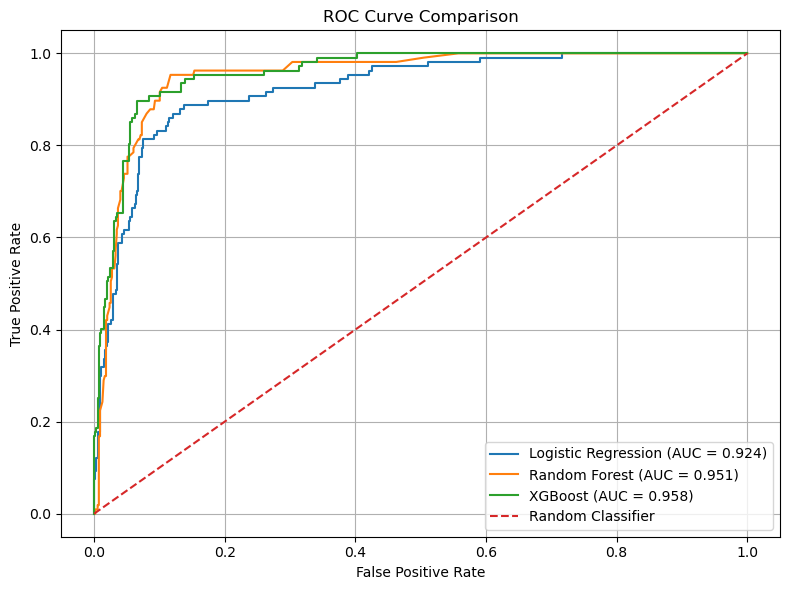

In [45]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_results['Logistic Regression']:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {roc_results['Random Forest']:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {roc_results['XGBoost']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Model Selection

Based on the evaluation results on the held-out test set, XGBoost was selected as the final candidate model for deployment.

XGBoost achieved:

- Accuracy: 91.13%
- Precision: 75.26%
- Recall: 68.22%
- F1-Score: 71.57%
- ROC-AUC: 95.76%

Recall, F1-Score, and ROC-AUC were given particular consideration because the target variable is imbalanced and the objective is to identify customers who are likely to churn.

Random Forest achieved slightly higher precision (77.01%), while Logistic Regression was retained as the baseline for comparison.

In [46]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(xgb_model, "../models/xgboost_churn_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("XGBoost model saved successfully!")
print("Preprocessor saved successfully!")

XGBoost model saved successfully!
Preprocessor saved successfully!


In [47]:
import joblib

loaded_model = joblib.load("../models/xgboost_churn_model.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model loaded successfully:", type(loaded_model))
print("Preprocessor loaded successfully:", type(loaded_preprocessor))

Model loaded successfully: <class 'xgboost.sklearn.XGBClassifier'>
Preprocessor loaded successfully: <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [48]:
from src.predict import predict_churn

sample_customer = {
    "Tenure": 5,
    "WarehouseToHome": 15,
    "NumberOfDeviceRegistered": 3,
    "PreferredOrderCat": "Laptop & Accessory",
    "SatisfactionScore": 3,
    "MaritalStatus": "Single",
    "NumberOfAddress": 2,
    "Complain": 0,
    "DaySinceLastOrder": 5,
    "CashbackAmount": 150
}

prediction, probability = predict_churn(sample_customer)

print("Prediction:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: 0
Churn Probability: 1.09 %
